# Low-Rank Optimal Transport via Factor Relaxation with Latent Coupling (FRLC)


This tutorial presents **FRLC** (*Factor Relaxation with Latent Coupling*), introduced by [Halmos et al., NeurIPS 2024](https://proceedings.neurips.cc/paper_files/paper/2024/file/cfc1924c62e72e2cb0e0feeecb963241-Paper-Conference.pdf).
The official implementation is available at [raphael-group/FRLC](https://github.com/raphael-group/FRLC).

FRLC is a low-rank optimal transport solver that replaces the shared inner marginal of [`LRSinkhorn`](https://ott-jax.readthedocs.io/en/latest/_autosummary/ott.solvers.linear.sinkhorn_lr.LRSinkhorn.html) with a full latent coupling $\mathbf{T}$, enabling richer cluster-to-cluster transport representations while keeping the same $O((n+m)r)$ memory footprint.

## Outline

1. [Background: the latent coupling factorization](#background)
2. [Algorithm: coordinate mirror descent on $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$](#algorithm)
3. [OTT-JAX implementation](#implementation)
4. [Experiment 1 — Cost vs rank: FRLC and LRSinkhorn](#exp1)
5. [Experiment 2 — Interpretability: the latent coupling $\mathbf{T}$](#exp2)
6. [Summary](#summary)

## Setup

In [1]:
!pip install jax jaxlib ott-jax matplotlib numpy tqdm

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from ott.geometry.geometry import Geometry
from ott.problems.linear.linear_problem import LinearProblem
from ott.solvers.linear.sinkhorn import Sinkhorn
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

print("JAX version :", jax.__version__)
print("Devices     :", jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX version : 0.10.0
Devices     : [CpuDevice(id=0)]


---
<a id="background"></a>

## 1. Background: The Latent Coupling Factorization

### 1.1 From dense to low-rank OT

The Wasserstein problem seeks a coupling $\mathbf{P} \in \Pi(\mathbf{a},\mathbf{b})$ minimising $\langle \mathbf{C}, \mathbf{P} \rangle_F$.
Storing the full $n \times m$ matrix is $O(nm)$, which is prohibitive at scale.

**LRSinkhorn** (Scetbon et al., 2021) restricts $\mathbf{P}$ to nonnegative rank $\leq r$ via the *factored coupling* (FC):

$$\mathbf{P}_r = \mathbf{Q}\,\operatorname{diag}(1/\mathbf{g})\,\mathbf{R}^\top,
\qquad \mathbf{Q}\in\Pi_{\mathbf{a},\mathbf{g}},\;\mathbf{R}\in\Pi_{\mathbf{b},\mathbf{g}}$$

where $\mathbf{g}\in\Delta_r$ is a **single shared** inner marginal, enforced via Dykstra projections.

### 1.2 The latent coupling (LC) factorization

FRLC replaces the diagonal matrix $\operatorname{diag}(1/\mathbf{g})$ with a full $r\times r$ coupling $\mathbf{T}$ and allows the two inner marginals to differ:

$$\boxed{\mathbf{P}_r = \mathbf{Q}\,\operatorname{diag}(1/\mathbf{g}_Q)\;
\mathbf{T}\;\operatorname{diag}(1/\mathbf{g}_R)\,\mathbf{R}^\top}$$

| Symbol | Shape | Constraint |
|--------|-------|------------|
| $\mathbf{Q}$ | $n\times r$ | $\mathbf{Q}\mathbf{1}_r = \mathbf{a}$ |
| $\mathbf{R}$ | $m\times r$ | $\mathbf{R}\mathbf{1}_r = \mathbf{b}$ |
| $\mathbf{T}$ | $r\times r$ | $\mathbf{T}\in\Pi_{\mathbf{g}_Q,\mathbf{g}_R}$ |
| $\mathbf{g}_Q = \mathbf{Q}^\top\mathbf{1}_n$ | $r$ | free inner marginal |
| $\mathbf{g}_R = \mathbf{R}^\top\mathbf{1}_m$ | $r$ | free, may differ from $\mathbf{g}_Q$ |

Setting $\mathbf{T} = \operatorname{diag}(\mathbf{g})$ recovers the FC factorization: **the LC family strictly contains the FC family.**

Beyond raw cost, the main gain is **interpretability**: the latent coupling $\mathbf{T}$ is a small $r\times r$ transport plan between cluster representatives, and can be read directly as a cluster-to-cluster flow. This structure is invisible in the diagonal formulation of LRSinkhorn.

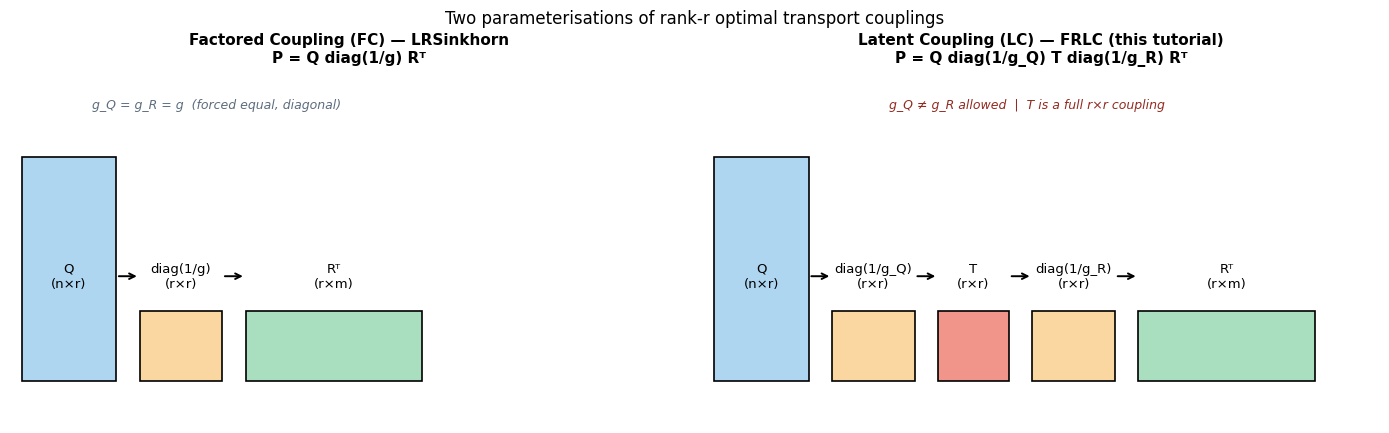

In [3]:
# ── Schematic comparison of the two factorizations ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

specs = [
    [("Q\n(n×r)",         0.2, 1.6, 3.2, "#AED6F1"),
     ("diag(1/g)\n(r×r)", 2.2, 1.4, 1.0, "#FAD7A0"),
     ("Rᵀ\n(r×m)",        4.0, 3.0, 1.0, "#A9DFBF")],
    [("Q\n(n×r)",            0.2, 1.6, 3.2, "#AED6F1"),
     ("diag(1/g_Q)\n(r×r)", 2.2, 1.4, 1.0, "#FAD7A0"),
     ("T\n(r×r)",            4.0, 1.2, 1.0, "#F1948A"),
     ("diag(1/g_R)\n(r×r)", 5.6, 1.4, 1.0, "#FAD7A0"),
     ("Rᵀ\n(r×m)",          7.4, 3.0, 1.0, "#A9DFBF")],
]
titles = [
    "Factored Coupling (FC) — LRSinkhorn\nP = Q diag(1/g) Rᵀ",
    "Latent Coupling (LC) — FRLC (this tutorial)\nP = Q diag(1/g_Q) T diag(1/g_R) Rᵀ",
]
subtitles = [
    "g_Q = g_R = g  (forced equal, diagonal)",
    "g_Q ≠ g_R allowed  |  T is a full r×r coupling",
]

for ax, spec, title, sub in zip(axes, specs, titles, subtitles):
    ax.set_xlim(0, 11.5); ax.set_ylim(0, 5.0); ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    for lbl, x, w, h, c in spec:
        ax.add_patch(plt.Rectangle((x, 0.6), w, h, color=c, ec="black", lw=1.2))
        ax.text(x + w/2, 2.1, lbl, ha="center", va="center", fontsize=9.5)
    for (_, x1, w1, *_), (_, x2, *_) in zip(spec, spec[1:]):
        ax.annotate("", xy=(x2, 2.1), xytext=(x1+w1, 2.1),
                    arrowprops=dict(arrowstyle="->", lw=1.4))
    ax.text(5.5 if len(spec) > 3 else 3.5, 4.5, sub,
            ha="center", fontsize=9, style="italic",
            color="#922B21" if len(spec) > 3 else "#5D6D7E")

plt.tight_layout()
plt.suptitle("Two parameterisations of rank-r optimal transport couplings",
             y=1.02, fontsize=12)
plt.savefig("fig_factorizations.png", dpi=150, bbox_inches="tight")
plt.show()

---
<a id="algorithm"></a>

## 2. Algorithm: Coordinate Mirror Descent on $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$

FRLC minimizes the primal OT cost $L(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ based on the latent coupling factorization:  $$L(\mathbf{Q}, \mathbf{R}, \mathbf{T}) = \langle \mathbf{C}, \mathbf{Q} \mathbf{X} \mathbf{R}^\top \rangle_F$$where the latent matrix $\mathbf{X}$ links the sub-couplings via separate inner marginals $\mathbf{g}_Q$ and $\mathbf{g}_R$:  $$\mathbf{X} = \operatorname{diag}(1/\mathbf{g}_Q) \, \mathbf{T} \, \operatorname{diag}(1/\mathbf{g}_R)$$The optimization is performed via block coordinate mirror descent, alternating between two blocks per iteration.  

$$\begin{array}{ll}
\textbf{Input:} & \mathbf{C},\,r,\,\mathbf{a},\,\mathbf{b},\,\tau,\,\gamma \\[0.5em]
1. & \mathbf{g}_Q,\mathbf{g}_R \leftarrow \tfrac{1}{r}\mathbf{1}_r \\[0.4em]
2. & \mathbf{Q}_0,\mathbf{R}_0,\mathbf{T}_0,\mathbf{X}_0 \leftarrow
     \text{InitCouplings}(\mathbf{a},\mathbf{b},\mathbf{g}_Q,\mathbf{g}_R) \\[0.4em]
3. & \textbf{while }\Delta_k > \varepsilon \\[0.4em]
4. & \qquad \nabla_Q,\nabla_R,\gamma_k \leftarrow
     \text{FactorGrad}(\mathbf{C},\mathbf{Q}_k,\mathbf{R}_k,\mathbf{X}_k,\gamma) \\[0.4em]
5. & \qquad \varepsilon_k = \gamma_k^{-1},\quad
     \mathbf{C}_Q^{(k)} = \nabla_Q - \varepsilon_k\log\mathbf{Q}_k,\quad
     \mathbf{C}_R^{(k)} = \nabla_R - \varepsilon_k\log\mathbf{R}_k \\[0.4em]
6. & \qquad \mathbf{Q}_{k+1} \leftarrow
     \mathrm{SRR}(\mathbf{C}_Q^{(k)},\mathbf{a},\mathbf{g}_Q,\;
     \tau_b=\tfrac{\tau}{\tau+\varepsilon_k}) \\[0.4em]
7. & \qquad \mathbf{R}_{k+1} \leftarrow
     \mathrm{SRR}(\mathbf{C}_R^{(k)},\mathbf{b},\mathbf{g}_R,\;
     \tau_b=\tfrac{\tau}{\tau+\varepsilon_k}) \\[0.4em]
8. & \qquad \mathbf{g}_Q,\mathbf{g}_R \leftarrow
     \mathbf{Q}_{k+1}^\top\mathbf{1}_n,\;\mathbf{R}_{k+1}^\top\mathbf{1}_m \\[0.4em]
9. & \qquad \nabla_T,\gamma_T \leftarrow
     \text{LatentGrad}(\mathbf{C},\mathbf{Q}_{k+1},\mathbf{R}_{k+1},
     \mathbf{g}_Q,\mathbf{g}_R,\gamma) \\[0.4em]
10.& \qquad \varepsilon_T = \gamma_T^{-1},\quad
     \mathbf{C}_T^{(k)} = \nabla_T - \varepsilon_T\log\mathbf{T}_k \\[0.4em]
11.& \qquad \mathbf{T}_{k+1} \leftarrow
     \mathrm{Sinkhorn}(\mathbf{C}_T^{(k)},\mathbf{g}_Q,\mathbf{g}_R) \\[0.4em]
12.& \qquad \mathbf{X}_{k+1} =
     \operatorname{diag}(1/\mathbf{g}_Q)\,\mathbf{T}_{k+1}\,
     \operatorname{diag}(1/\mathbf{g}_R) \\[0.4em]
\textbf{Output:} & \mathbf{P}_r = \mathbf{Q}\mathbf{X}\mathbf{R}^\top
\end{array}$$

Each outer iteration resolves exactly **three Sinkhorn sub-problems**, all via OTT-JAX:

| Update | OTT call | Marginal regime |
|--------|----------|-----------------|
| $\mathbf{Q}$ | `Sinkhorn` with `tau_a=1, tau_b=τ/(τ+ε_k)` | hard left $\mathbf{a}$, soft right |
| $\mathbf{R}$ | `Sinkhorn` with `tau_a=1, tau_b=τ/(τ+ε_k)` | hard left $\mathbf{b}$, soft right |
| $\mathbf{T}$ | `Sinkhorn` with `tau_a=tau_b=1` | balanced $\mathbf{g}_Q, \mathbf{g}_R$ |

No Dykstra projections are needed: the coordinate split decouples the constraint
sets naturally, and Sinkhorn alone suffices.

---
<a id="implementation"></a>

## 3. OTT-JAX Implementation

### 3.1 Sinkhorn sub-problem wrapper

All three sub-problems are routed through OTT-JAX's `LinearProblem + Sinkhorn` interface. The `tau_a` / `tau_b` parameters select balanced vs semi-relaxed regimes, and dual potentials are warm-started across outer iterations.

In [4]:
class OTSubproblemSolver:
    """OTT-JAX Sinkhorn wrapper for the three FRLC sub-problems.

    Exposes a unified interface for balanced OT (tau_a = tau_b = 1) and
    right semi-relaxed OT (tau_a = 1, tau_b < 1).
    Dual warm-starting is supported to accelerate the inner Sinkhorn loops.
    """

    def __init__(self, max_iters: int = 500, threshold: float = 1e-8):
        self._solver = Sinkhorn(threshold=threshold, max_iterations=max_iters)

    def project(self, cost_mat, marginal_a, marginal_b,
                warm_start, epsilon, tau_a, tau_b):
        geom = Geometry(cost_matrix=cost_mat, epsilon=epsilon)
        prob = LinearProblem(geom, a=marginal_a, b=marginal_b,
                             tau_a=tau_a, tau_b=tau_b)
        out = (self._solver(prob) if warm_start[0] is None
               else self._solver(prob, init=warm_start))
        return out.matrix, out.f, out.g

print("OTSubproblemSolver defined.")

OTSubproblemSolver defined.


### 3.2 Initialisation

The sub-couplings are initialised by projecting random positive kernels $\mathbf{K} = e^{\mathbf{C}_{\text{rand}}}$ onto the required marginals via balanced
Sinkhorn, following Algorithm 6 of the paper. The initial inner marginals are set uniformly: $\mathbf{g}_Q = \mathbf{g}_R = \tfrac{1}{r}\mathbf{1}_r$.

In [5]:
def build_initial_factors(marginal_a, marginal_b, inner_a, inner_b,
                          epsilon=1.0, threshold=1e-8, max_iter=500):
    """Initialise (Q, R, T, X) following Algorithm 6 of Halmos et al. 2024.

    Random uniform matrices are used as cost matrices for initial Sinkhorn
    projections, giving a full-rank starting point in Pi_r(a, b).

    Parameters
    ----------
    marginal_a, marginal_b : source and target marginals
    inner_a, inner_b       : initial inner marginals (uniform 1/r)
    epsilon                : Sinkhorn regularisation for initialisation
    """
    dtype = marginal_a.dtype
    n, m  = marginal_a.shape[0], marginal_b.shape[0]
    rQ, rR = inner_a.shape[0], inner_b.shape[0]

    key = jax.random.PRNGKey(0)
    k1, k2, k3 = jax.random.split(key, 3)

    cost_init_Q = jax.random.uniform(k1, (n,  rQ), dtype=dtype)
    cost_init_R = jax.random.uniform(k2, (m,  rR), dtype=dtype)
    cost_init_T = jax.random.uniform(k3, (rQ, rR), dtype=dtype)

    solver = Sinkhorn(threshold=threshold, max_iterations=max_iter)

    def _balanced_proj(cost_rand, marg_left, marg_right):
        geom = Geometry(cost_matrix=-float(epsilon)*cost_rand, epsilon=float(epsilon))
        return solver(LinearProblem(geom, a=marg_left, b=marg_right)).matrix

    Q = _balanced_proj(cost_init_Q, marginal_a, inner_a)
    R = _balanced_proj(cost_init_R, marginal_b, inner_b)

    gQ_actual = Q.T @ jnp.ones(n, dtype=dtype)
    gR_actual = R.T @ jnp.ones(m, dtype=dtype)

    T = _balanced_proj(cost_init_T, gQ_actual, gR_actual)
    X = jnp.diag(1.0 / gQ_actual) @ T @ jnp.diag(1.0 / gR_actual)

    return Q, R, T, X

print("build_initial_factors defined.")

build_initial_factors defined.


### 3.3 Factor gradients for $\mathbf{Q}$ and $\mathbf{R}$

The Wasserstein gradients with rank-1 corrections (Appendix B of the paper):

$$\nabla_Q = \mathbf{C}\mathbf{R}\mathbf{X}^\top
  - \mathbf{1}_n\,\operatorname{diag}^{-1}\!
  \left((\mathbf{C}\mathbf{R}\mathbf{X}^\top)^\top
  \mathbf{Q}\,\operatorname{diag}(1/\mathbf{g}_Q)\right)^\top$$

$$\nabla_R = \mathbf{C}^\top\mathbf{Q}\mathbf{X}
  - \mathbf{1}_m\,\operatorname{diag}^{-1}\!
  \left(\operatorname{diag}(1/\mathbf{g}_R)\,
  \mathbf{R}^\top\mathbf{C}^\top\mathbf{Q}\mathbf{X}\right)^\top$$

The shared $\ell^\infty$-normalised step size is:
$\gamma_k = \gamma / \max(\|\nabla_Q\|_\infty, \|\nabla_R\|_\infty)$.

In [6]:
@jax.jit
def factor_gradients_and_stepsize(C, Q, R, X, gamma):
    """Rank-1-corrected factor gradients and normalised step size (Algorithm 1)."""
    # grad_Q = C R X^T - 1_n w1^T
    raw_gradQ = (C @ R) @ X.T
    gQ = jnp.sum(Q, axis=0)
    w1 = jnp.sum(raw_gradQ * Q, axis=0) / gQ
    grad_Q = raw_gradQ - w1[None, :]

    # grad_R = C^T Q X - 1_m w2^T
    raw_gradR = (C.T @ Q) @ X
    gR = jnp.sum(R, axis=0)
    w2 = jnp.sum(R * raw_gradR, axis=0) / gR
    grad_R = raw_gradR - w2[None, :]
    gamma_k = gamma / (jnp.maximum(jnp.max(jnp.abs(grad_Q)), jnp.max(jnp.abs(grad_R))))
    return grad_Q, grad_R, gamma_k
    
print("factor_gradients_and_stepsize defined.")

factor_gradients_and_stepsize defined.


### 3.4 Latent coupling gradient for $\mathbf{T}$

$$\nabla_T =
  \operatorname{diag}(1/\mathbf{g}_Q)\,\mathbf{Q}^\top\mathbf{C}\mathbf{R}\,
  \operatorname{diag}(1/\mathbf{g}_R), \qquad
  \gamma_T = \frac{\gamma}{\|\nabla_T\|_\infty}, \qquad
  \varepsilon_T = \gamma_T^{-1}$$

The mirror-descent step is written as an OTT cost matrix:        
$\mathbf{C}_T^{(k)} = \nabla_T - \varepsilon_T \log \mathbf{T}_k.$

In [7]:
def latent_gradient_and_stepsize(C, Q, R, X, gQ, gR, gamma):
    """Latent coupling gradient and normalised step size for T (Algorithm 1)."""
    gamma_T = gamma / jnp.max(jnp.abs((Q.T @ C @ R) / (gQ[:, None] * gR[None, :])))
    return (Q.T @ C @ R) / (gQ[:, None] * gR[None, :]), gamma_T

print("latent_gradient_and_stepsize defined.")

latent_gradient_and_stepsize defined.


### 3.5 Convergence criterion

The outer loop terminates once the squared iterate change (Eq. 10 of the paper) falls below tolerance $\varepsilon$:

$$\Delta_k =
  \frac{1}{\gamma_k^2}
  \Bigl(\|\mathbf{Q}_{k+1}-\mathbf{Q}_k\|_F^2
        +\|\mathbf{R}_{k+1}-\mathbf{R}_k\|_F^2
        +\|\mathbf{T}_{k+1}-\mathbf{T}_k\|_F^2\Bigr)$$

In [8]:
@jax.jit
def iterate_change(current, previous, gamma_k):
    """Normalised squared iterate change — stopping criterion (Eq. 10)."""
    Q, R, T         = current
    Q_prev, R_prev, T_prev = previous
    return (gamma_k ** -2) * (
        jnp.linalg.norm(Q - Q_prev) ** 2
        + jnp.linalg.norm(R - R_prev) ** 2
        + jnp.linalg.norm(T - T_prev) ** 2
    )

print("iterate_change defined.")

iterate_change defined.


### 3.6 Main solver

The functions above are assembled into `run_frlc`, which performs the coordinate mirror-descent loop and returns the LC factors $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ together with the cost history.

In [9]:
def run_frlc(
    C,
    a=None, b=None,
    tau=50.0,
    gamma=70.0,
    rank=10,
    rank2=None,
    max_outer=200,
    min_outer=25,
    tol=1e-5,
    max_inner=500,
    return_costs=True,
):
    """Balanced FRLC via block coordinate mirror descent (Halmos et al., 2024).

    Solves  min_{P in Pi_r(a,b)} <C, P>_F  using the LC factorization
    P = Q diag(1/gQ) T diag(1/gR) R^T.

    Each outer iteration calls three OTT-JAX Sinkhorn sub-problems:
      (1) right semi-relaxed OT for Q  — tau_a=1, tau_b=tau/(tau+eps_k)
      (2) right semi-relaxed OT for R  — same tau_b
      (3) balanced OT for T            — tau_a=tau_b=1

    Parameters
    ----------
    C          : cost matrix (n, m)
    a, b       : marginals — uniform if None
    tau, gamma : relaxation and step-size scale
    rank       : latent rank r
    max_outer  : maximum outer iterations
    min_outer  : minimum outer iterations before convergence check
    tol        : convergence tolerance on Delta_k
    max_inner  : Sinkhorn iterations for each sub-problem
    return_costs : if True, return list of primal costs per iteration

    Returns
    -------
    Q, R, T  : LC factors
    costs    : list of primal transport costs (if return_costs=True)
    """
    N1, N2  = C.shape
    ones_N1 = jnp.ones(N1, dtype=C.dtype)
    ones_N2 = jnp.ones(N2, dtype=C.dtype)

    if a is None: a = ones_N1 / N1
    if b is None: b = ones_N2 / N2
    if rank2 is None: rank2 = rank

    inner_marg_Q = jnp.ones(rank,  dtype=C.dtype) / rank
    inner_marg_R = jnp.ones(rank2, dtype=C.dtype) / rank2

    Q, R, T, X = build_initial_factors(a, b, inner_marg_Q, inner_marg_R,
                                        epsilon=gamma)

    sub_Q = OTSubproblemSolver(max_iters=max_inner)
    sub_R = OTSubproblemSolver(max_iters=max_inner)
    sub_T = OTSubproblemSolver(max_iters=max_inner)

    Q_prev = R_prev = T_prev = None
    f1Q = f2Q = f1R = f2R = f1T = f2T = None
    gamma_k = gamma
    costs   = []
    k       = 0

    while k < max_outer and (
        k < min_outer
        or iterate_change((Q, R, T), (Q_prev, R_prev, T_prev), gamma_k) > tol
    ):
        Q_prev, R_prev, T_prev = Q, R, T

        # Step 1: factor relaxation (Q and R independently)
        grad_Q, grad_R, gamma_k = factor_gradients_and_stepsize(C, Q, R, X, gamma)
        eps   = float(gamma_k ** -1)
        tau_b = tau / (tau + eps)

        cost_Q = grad_Q - eps * jnp.log(Q)
        cost_R = grad_R - eps * jnp.log(R)

        Q, f1Q, f2Q = sub_Q.project(cost_Q, a,  Q.T @ ones_N1,
                                      (f1Q, f2Q), eps, 1.0, tau_b)
        R, f1R, f2R = sub_R.project(cost_R, b,  R.T @ ones_N2,
                                      (f1R, f2R), eps, 1.0, tau_b)

        gQ = Q.T @ ones_N1
        gR = R.T @ ones_N2

        # Step 2: latent coupling update (T) 
        grad_T, gamma_T = latent_gradient_and_stepsize(C, Q, R, X, gQ, gR, gamma)
        eps_T  = float(gamma_T ** -1)
        cost_T = grad_T - eps_T * jnp.log(T)

        T, f1T, f2T = sub_T.project(cost_T, gQ, gR, (f1T, f2T),
                                      eps_T, 1.0, 1.0)

        X = jnp.diag(1.0 / gQ) @ T @ jnp.diag(1.0 / gR)

        # Primal cost via trace identity
        cost = float(jnp.trace(((Q.T @ C) @ R) @ X.T))
        costs.append(cost)
        k += 1

    return (Q, R, T, costs) if return_costs else (Q, R, T)

print("run_frlc defined.")

run_frlc defined.


### 3.7 LC-projection and visualisation helpers

The **LC-projection** (Definition 4.1 of the paper) maps source and target datasets onto $r$ barycentric cluster representatives:

$$\mathbf{Y}^{(1)} = \operatorname{diag}(1/\mathbf{g}_Q)\,\mathbf{Q}^\top\mathbf{Z}^{(1)},
\qquad
\mathbf{Y}^{(2)} = \operatorname{diag}(1/\mathbf{g}_R)\,\mathbf{R}^\top\mathbf{Z}^{(2)}$$

Row $k$ of $\mathbf{Y}^{(1)}$ is the weighted centroid of source points assigned to latent cluster $k$. The latent coupling $\mathbf{T}$ then encodes how these cluster representatives are transported — a compact summary that has no direct equivalent in LRSinkhorn.

In [10]:
def compute_lc_projections(src_pts, tgt_pts, Q, R):
    """Barycentric cluster representatives from LC sub-couplings.

    Follows Definition 4.1 of Halmos et al. 2024.

    Parameters
    ----------
    src_pts, tgt_pts : point clouds, shape (n, d) and (m, d)
    Q                : left sub-coupling,  shape (n, r)
    R                : right sub-coupling, shape (m, r)

    Returns
    -------
    Y_src : source barycenters, shape (r, d)
    Y_tgt : target barycenters, shape (r, d)
    """
    gQ = jnp.sum(Q, axis=0)
    gR = jnp.sum(R, axis=0)
    return (Q.T @ src_pts) / gQ[:, None], (R.T @ tgt_pts) / gR[:, None]


def draw_transport_plan(src, tgt, bary_src, bary_tgt, T_mat,
                        title="", linewidth_scale=20):
    """Scatter plot with arrows between LC barycenters, weighted by T."""
    plt.scatter(src[:, 0],      src[:, 1],      color="orange",   alpha=0.2,
                label="Source", s=10)
    plt.scatter(tgt[:, 0],      tgt[:, 1],      color="green",    alpha=0.2,
                label="Target", s=10)
    plt.scatter(bary_src[:, 0], bary_src[:, 1], color="royalblue",
                s=90, zorder=5, label="Source barycenters $Y^{(1)}$")
    plt.scatter(bary_tgt[:, 0], bary_tgt[:, 1], color="crimson",
                s=90, zorder=5, label="Target barycenters $Y^{(2)}$")
    for i in range(bary_src.shape[0]):
        for j in range(bary_tgt.shape[0]):
            mass = float(T_mat[i, j])
            if mass > 0:
                plt.plot([bary_src[i, 0], bary_tgt[j, 0]],
                         [bary_src[i, 1], bary_tgt[j, 1]],
                         c="steelblue", alpha=0.65,
                         linewidth=mass * linewidth_scale)
    plt.title(title)
    plt.axis("off")
    plt.legend(loc="upper right", fontsize=8)

print("compute_lc_projections and draw_transport_plan defined.")

compute_lc_projections and draw_transport_plan defined.


---
<a id="exp1"></a>

## 4. Experiment 1 — Cost vs Rank: FRLC and LRSinkhorn

We evaluate both solvers on the synthetic benchmark from the paper.

- **Source**: 1000 points from eight isotropic 2D Gaussians on a unit circle (scaled by 5).
- **Target**: 1000 points from the two-moons distribution (scaled to $[-1, 2]^2$).
- **Cost**: Euclidean distance, normalised to $[0,1]$.
- **Ranks**: $r \in \{5, 10, \ldots, 50\}$.

In practice, the two methods yield **very similar primal costs** across all ranks. The differences are typically within a few percent, and LRSinkhorn can sometimes report a slightly lower value depending on the random seed and stopping criterion. This is expected: both methods are solving the same problem in the same function class, and the gap shrinks as $r$ increases.

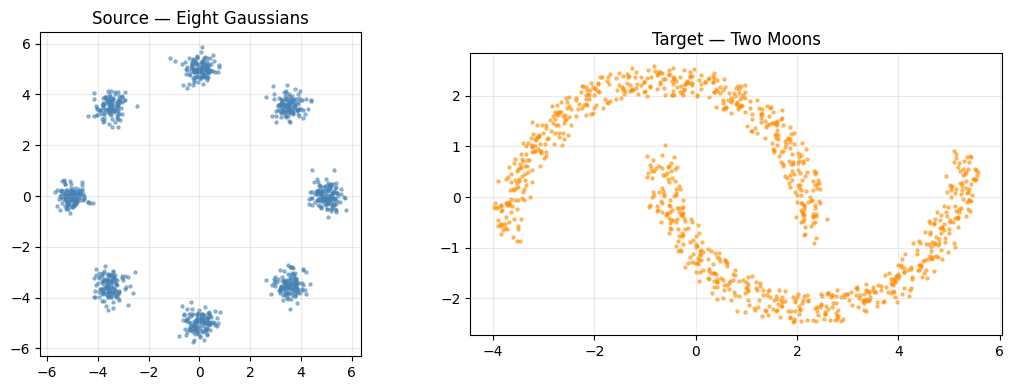

Cost matrix: (1000, 1000), max=1.0000


In [11]:
def generate_eight_gaussians(rng, n, radius=5.0, variance=0.1):
    rng_c, rng_n = jax.random.split(rng)
    centers = jnp.array([
        (1,0),(-1,0),(0,1),(0,-1),
        (1/jnp.sqrt(2), 1/jnp.sqrt(2)),
        (1/jnp.sqrt(2),-1/jnp.sqrt(2)),
        (-1/jnp.sqrt(2), 1/jnp.sqrt(2)),
        (-1/jnp.sqrt(2),-1/jnp.sqrt(2)),
    ]) * radius
    idx   = jax.random.randint(rng_c, (n,), 0, 8)
    noise = jax.random.normal(rng_n, (n, 2)) * jnp.sqrt(variance)
    return centers[idx] + noise


def generate_two_moons(rng, n, noise_level=0.2):
    n_upper, n_lower = n // 2, n - n // 2
    t_up  = jnp.linspace(0, jnp.pi, n_upper)
    t_lo  = jnp.linspace(0, jnp.pi, n_lower)
    upper = jnp.stack([jnp.cos(t_up),  jnp.sin(t_up)],            axis=1)
    lower = jnp.stack([1 - jnp.cos(t_lo), 1 - jnp.sin(t_lo) - 0.5], axis=1)
    pts   = jnp.concatenate([upper, lower], axis=0)
    pts   = pts + noise_level * jax.random.uniform(
                jax.random.split(rng, 1)[0], pts.shape)
    return pts * 3.0 - 1.0


rng  = jax.random.PRNGKey(42)
rng1, rng2 = jax.random.split(rng, 2)
N    = 1000

src_pts = generate_eight_gaussians(rng1, N)
tgt_pts = generate_two_moons(rng2, N)

a = jnp.ones(N) / N
b = jnp.ones(N) / N

C = jnp.linalg.norm(src_pts[:, None, :] - tgt_pts[None, :, :], axis=-1)
C = C / jnp.max(C)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(src_pts[:,0], src_pts[:,1], s=5, alpha=0.5, color="steelblue")
axes[0].set_title("Source — Eight Gaussians", fontsize=12)
axes[1].scatter(tgt_pts[:,0], tgt_pts[:,1], s=5, alpha=0.5, color="darkorange")
axes[1].set_title("Target — Two Moons", fontsize=12)
for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cost matrix: {C.shape}, max={float(C.max()):.4f}")

### Rank sweep — collecting costs

In [12]:
geom_lr = Geometry(cost_matrix=C, epsilon=1e-2)
ot_prob = linear_problem.LinearProblem(geom_lr, a, b)

rank_grid     = list(range(5, 51, 5))
costs_frlc    = []
costs_lot     = []

for rk in tqdm(rank_grid, desc="Rank sweep"):
    _, _, _, errs = run_frlc(
        C, rank=rk, tau=60, gamma=80,
        min_outer=10, max_outer=200, max_inner=300,
    )
    costs_frlc.append(errs[-1])

    out_lr = sinkhorn_lr.LRSinkhorn(rank=rk, max_iterations=500)(ot_prob)
    costs_lot.append(float(out_lr.primal_cost))

print("\n Rank | FRLC     | LOT      | diff     | lower")
print("-" * 55)
for rk, fc, lc in zip(rank_grid, costs_frlc, costs_lot):
    diff   = fc - lc
    winner = "FRLC" if fc < lc else "LOT "
    print(f"  {rk:3d} | {fc:.5f} | {lc:.5f} | {diff:+.5f} | {winner}")

Rank sweep: 100%|██████████| 10/10 [05:11<00:00, 31.15s/it]


 Rank | FRLC     | LOT      | diff     | lower
-------------------------------------------------------
    5 | 0.28095 | 0.27401 | +0.00694 | LOT 
   10 | 0.24257 | 0.23758 | +0.00498 | LOT 
   15 | 0.23714 | 0.23255 | +0.00459 | LOT 
   20 | 0.23326 | 0.22981 | +0.00345 | LOT 
   25 | 0.23057 | 0.23059 | -0.00002 | FRLC
   30 | 0.23114 | 0.22810 | +0.00304 | LOT 
   35 | 0.22958 | 0.22795 | +0.00163 | LOT 
   40 | 0.22904 | 0.22767 | +0.00137 | LOT 
   45 | 0.22937 | 0.22760 | +0.00177 | LOT 
   50 | 0.22910 | 0.22770 | +0.00139 | LOT 


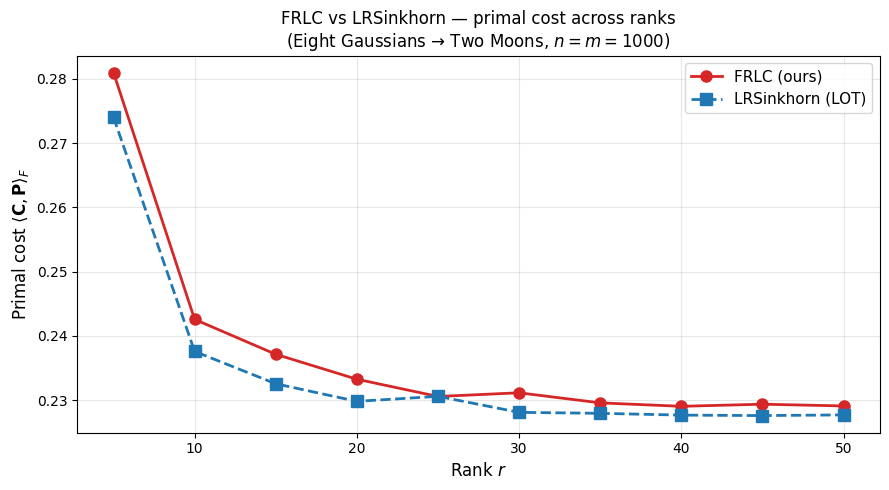

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rank_grid, costs_frlc, "o-",  color="tab:red",  lw=2, ms=8,
        label="FRLC (ours)")
ax.plot(rank_grid, costs_lot,  "s--", color="tab:blue", lw=2, ms=8,
        label="LRSinkhorn (LOT)")
ax.set_xlabel("Rank $r$", fontsize=12)
ax.set_ylabel(r"Primal cost $\langle\mathbf{C},\mathbf{P}\rangle_F$", fontsize=12)
ax.set_title("FRLC vs LRSinkhorn — primal cost across ranks\n"
             "(Eight Gaussians → Two Moons, $n=m=1000$)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_rank_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation.** The two methods achieve **comparable primal costs** across all ranks.
Neither dominates the other by a large margin: differences are typically within 1–3%, and LRSinkhorn can report a slightly lower value on some configurations.

This is not surprising both algorithms optimise over the same set of nonneg rank-$r$ couplings, and the problem becomes easier as $r$ grows. What FRLC brings is not primarily a raw cost advantage, but a richer structure in the solution:

- The latent coupling $\mathbf{T}$ is a full $r\times r$ transport plan between cluster representatives, readable as a cluster-to-cluster flow.
- LRSinkhorn's diagonal $\operatorname{diag}(\mathbf{g})$ carries no such information.
- This difference becomes decisive when the source and target have different numbers of clusters as Experiment 2 demonstrates.

### Convergence of the primal cost

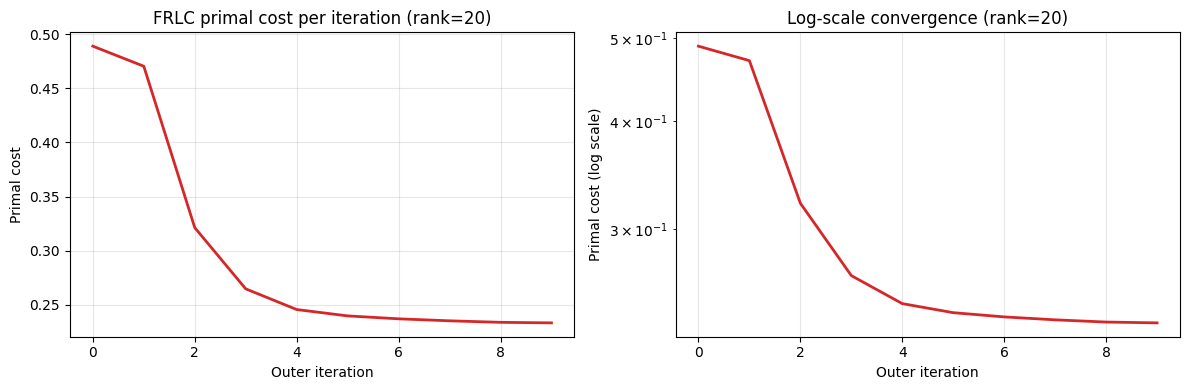

Final cost: 0.23326 in 10 iterations


In [14]:
_, _, _, demo_costs = run_frlc(
    C, rank=20, tau=60, gamma=80,
    min_outer=10, max_outer=200, max_inner=300,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(demo_costs, color="tab:red", lw=2)
axes[0].set_xlabel("Outer iteration"); axes[0].set_ylabel("Primal cost")
axes[0].set_title("FRLC primal cost per iteration (rank=20)")
axes[0].grid(alpha=0.3)

axes[1].semilogy(demo_costs, color="tab:red", lw=2)
axes[1].set_xlabel("Outer iteration"); axes[1].set_ylabel("Primal cost (log scale)")
axes[1].set_title("Log-scale convergence (rank=20)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final cost: {demo_costs[-1]:.5f} in {len(demo_costs)} iterations")

---
<a id="exp2"></a>

## 5. Experiment 2 — Interpretability: the Latent Coupling $\mathbf{T}$

Raw cost aside, FRLC's main advantage is the **interpretability of $\mathbf{T}$**.
We study this on a controlled dataset where the ground-truth cluster structure is known.

- **Source**: 1000 points from 5 Gaussians at the 5th roots of unity (radius 2).
- **Target**: 1000 points from 10 Gaussians at the 10th roots of unity (radius 4).
- **Rank**: $r = 5$ (equal to the number of source clusters).

With $r=5$ and 10 target clusters, each source cluster must **split its mass** across two target clusters. A diagonal $\mathbf{T} = \operatorname{diag}(\mathbf{g})$ cannot represent this splitting: it maps each source latent component to exactly one target component. FRLC's full $\mathbf{T}$ captures the split naturally.

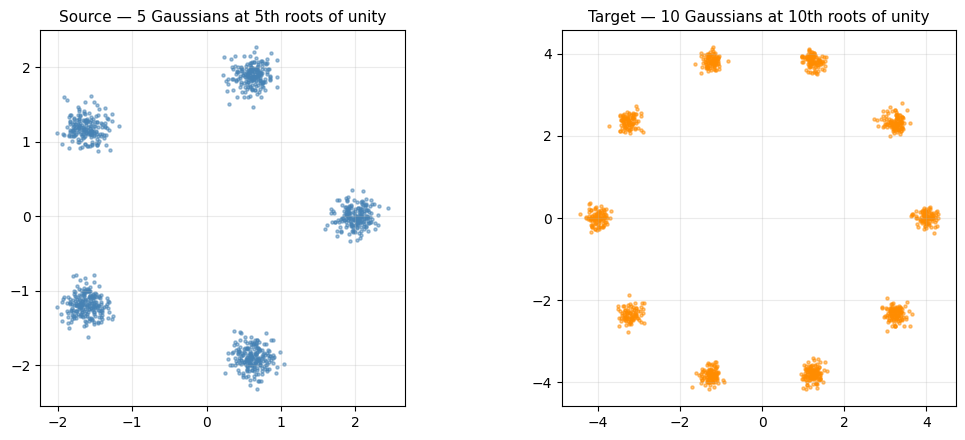

In [ ]:
def generate_roots_of_unity(rng, n, k, radius=1.0, variance=0.01):
    """Sample n points from k Gaussians at the k-th roots of unity."""
    angles  = jnp.linspace(0, 2*jnp.pi, k, endpoint=False)
    centers = radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)
    rng_c, rng_n = jax.random.split(rng)
    idx   = jax.random.randint(rng_c, (n,), 0, k)
    noise = jax.random.normal(rng_n, (n, 2)) * jnp.sqrt(variance)
    return centers[idx] + noise


rng3, rng4 = jax.random.split(jax.random.PRNGKey(7), 2)
N2 = 1000

z_src = generate_roots_of_unity(rng3, N2, k=5,  radius=2.0, variance=0.02)
z_tgt = generate_roots_of_unity(rng4, N2, k=10, radius=4.0, variance=0.02)

C_interp = jnp.linalg.norm(z_src[:, None, :] - z_tgt[None, :, :], axis=-1)
C_interp  = C_interp / jnp.max(C_interp)
a2 = jnp.ones(N2) / N2
b2 = jnp.ones(N2) / N2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(z_src[:,0], z_src[:,1], s=5, alpha=0.5, color="steelblue")
axes[0].set_title("Source — 5 Gaussians at 5th roots of unity", fontsize=11)
axes[1].scatter(z_tgt[:,0], z_tgt[:,1], s=5, alpha=0.5, color="darkorange")
axes[1].set_title("Target — 10 Gaussians at 10th roots of unity", fontsize=11)
for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
r_interp = 5

# FRLC
Q_f, R_f, T_f, costs_f = run_frlc(
    C_interp, a=a2, b=b2,
    rank=r_interp, tau=60, gamma=80,
    min_outer=10, max_outer=200, max_inner=300,
)

# LRSinkhorn
geom_i  = Geometry(cost_matrix=C_interp, epsilon=1e-2)
prob_i  = linear_problem.LinearProblem(geom_i, a2, b2)
out_lot = sinkhorn_lr.LRSinkhorn(rank=r_interp, max_iterations=500)(prob_i)

print(f"FRLC cost : {costs_f[-1]:.5f}")
print(f"LOT  cost : {float(out_lot.primal_cost):.5f}")

FRLC cost : 0.33920
LOT  cost : 0.33504


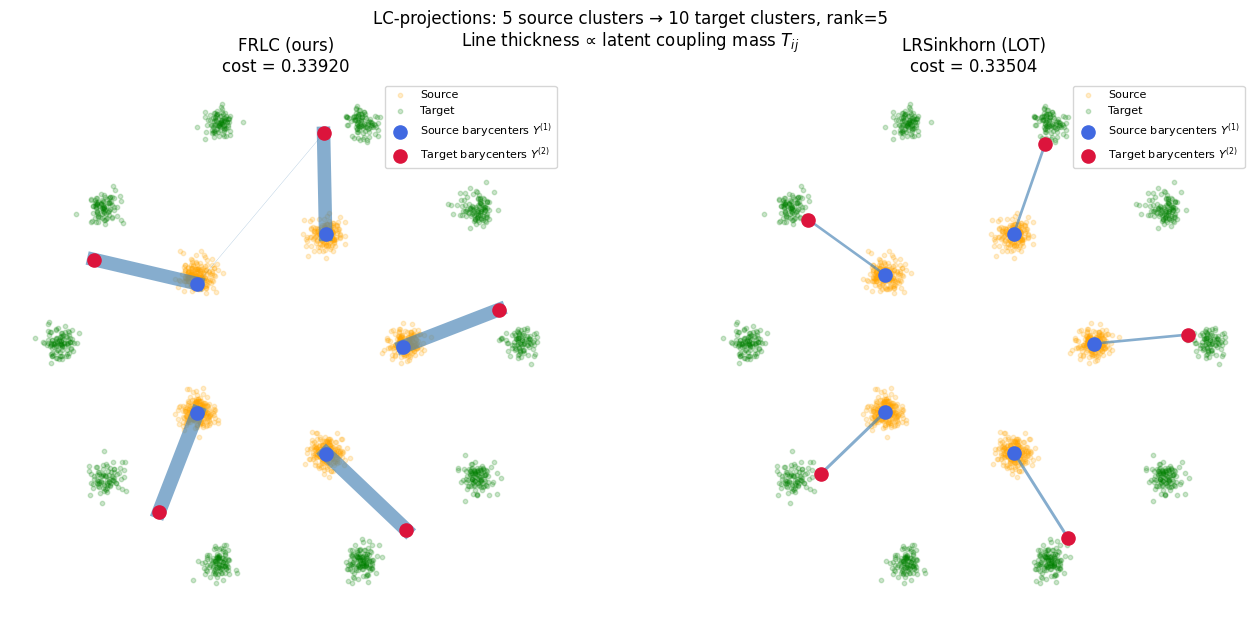

In [ ]:
# LC-projections for both methods
Y_src_f, Y_tgt_f = compute_lc_projections(z_src, z_tgt, Q_f, R_f)
Y_src_l, Y_tgt_l = compute_lc_projections(z_src, z_tgt,
                                            out_lot.q, out_lot.r)
T_lot = jnp.diag(out_lot.g)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Ys, Yt, T_mat, label, cost_v, lw_scale in [
    (axes[0], Y_src_f, Y_tgt_f, T_f,   "FRLC (ours)",
     costs_f[-1],                        50),
    (axes[1], Y_src_l, Y_tgt_l, T_lot, "LRSinkhorn (LOT)",
     float(out_lot.primal_cost),          10),
]:
    plt.sca(ax)
    draw_transport_plan(np.array(z_src), np.array(z_tgt),
                        np.array(Ys), np.array(Yt),
                        np.array(T_mat),
                        title=f"{label}\ncost = {cost_v:.5f}",
                        linewidth_scale=lw_scale)
    ax.set_aspect("equal")

plt.tight_layout()
plt.suptitle("LC-projections: 5 source clusters → 10 target clusters, rank=5\n"
             "Line thickness ∝ latent coupling mass $T_{ij}$", y=1.02, fontsize=12)
plt.savefig("fig_lc_projections.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation.**

- **FRLC** places source barycenters (blue) at the centers of the 5 source clusters and target barycenters (red) at the centers of 5 of the 10 target clusters. The latent coupling $\mathbf{T}$ shows each source cluster sending mass to the two geometrically nearest target clusters exactly the correct one-to-two splitting.

- **LRSinkhorn** is constrained to a diagonal $\mathbf{T} = \operatorname{diag}(\mathbf{g})$. With $r=5$ and 10 target clusters, the diagonal cannot express this splitting: the barycenters drift toward compromise positions, and the transport plan carries no interpretable cluster summary.

This is the setting where FRLC's structural advantage is clearest not necessarily in primal cost, but in the **quality of the latent decomposition** it provides.

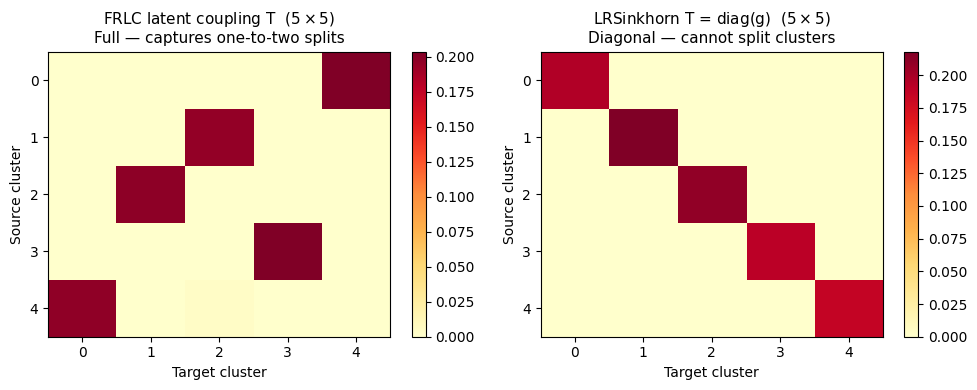

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(np.array(T_f), cmap="YlOrRd", aspect="auto")
axes[0].set_title("FRLC latent coupling T  ($5\\times5$)\nFull — captures one-to-two splits",
                  fontsize=11)
axes[0].set_xlabel("Target cluster"); axes[0].set_ylabel("Source cluster")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.array(T_lot), cmap="YlOrRd", aspect="auto")
axes[1].set_title("LRSinkhorn T = diag(g)  ($5\\times5$)\nDiagonal — cannot split clusters",
                  fontsize=11)
axes[1].set_xlabel("Target cluster"); axes[1].set_ylabel("Source cluster")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig("fig_T_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
<a id="summary"></a>

## 6. Summary

### FRLC vs LRSinkhorn a balanced view

Both FRLC and LRSinkhorn are efficient low-rank OT solvers with $O((n+m)r)$ memory and sub-quadratic runtime. In terms of **raw primal cost**, their performances are **close on balanced synthetic benchmarks** LRSinkhorn can even edge ahead on some configurations.

Where FRLC stands out is in the **structure of its solution**:

| Property | LRSinkhorn | FRLC |
|----------|-----------|------|
| Factorization | $\mathbf{Q}\,\operatorname{diag}(1/\mathbf{g})\,\mathbf{R}^\top$ | $\mathbf{Q}\,\operatorname{diag}(1/\mathbf{g}_Q)\,\mathbf{T}\,\operatorname{diag}(1/\mathbf{g}_R)\,\mathbf{R}^\top$ |
| Inner marginals | $\mathbf{g}_Q = \mathbf{g}_R$ forced | $\mathbf{g}_Q \neq \mathbf{g}_R$ free |
| Latent matrix | diagonal | full $r\times r$ coupling |
| Sub-routine | Dykstra + Sinkhorn | Sinkhorn only |
| Cluster interpretability | none | ✓ cluster-to-cluster flow via $\mathbf{T}$ |
| Handles asymmetric cluster counts | ✗ | ✓ (one-to-many splits in $\mathbf{T}$) |

### When to prefer FRLC

- The source and target distributions have **different numbers of clusters** the full $\mathbf{T}$ represents cluster splitting naturally, while the diagonal cannot.
- **Interpretability matters** downstream tasks (e.g., spatial transcriptomics slice alignment) benefit from the explicit cluster-to-cluster summary in $\mathbf{T}$.
- **Unbalanced transport** — FRLC extends directly to all four marginal modes (balanced, unbalanced, semi-relaxed left/right) without changing the algorithm structure.

### Extensions discussed in the paper

- **Gromov-Wasserstein FRLC** replaces the Wasserstein gradient with the GW gradient for comparing distributions on incomparable metric spaces.
- **Fused Gromov-Wasserstein FRLC** — applied in the paper to spatial transcriptomics alignment of mouse embryo slices ($n, m \approx 30\text{k}$–$50\text{k}$).

## References

- P. Halmos, X. Liu, J. Gold & B. J. Raphael (2024).
  *Low-Rank Optimal Transport through Factor Relaxation with Latent Coupling.*
  NeurIPS 2024.
  [Paper](https://proceedings.neurips.cc/paper_files/paper/2024/file/cfc1924c62e72e2cb0e0feeecb963241-Paper-Conference.pdf)
  · [Code](https://github.com/raphael-group/FRLC)
- M. Scetbon, M. Cuturi & G. Peyré (2021).
  *Low-Rank Sinkhorn Factorization.* ICML 2021.
- C.-H. Lin, M. Azabou & E. L. Dyer (2021).
  *Making transport more robust and interpretable by moving data through a small
  number of anchor points.* ICML 2021.
- M. Cuturi et al. (2022).
  *Optimal Transport Tools (OTT): A JAX Toolbox for all things Wasserstein.*
  arXiv 2201.12324.